In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from sklearn.utils.extmath import cartesian
from skimage.transform import rotate, AffineTransform, warp

rng = np.random.default_rng(seed=42)

In [3]:
def augShear(sample, shearconstraint):
    """
    This function takes in a sample and a shear constraint and returns the augmented sample
    by shearing the sample by a random amount within the shear constraint

    sample: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    shearconstraint: the maximum shear by which the sample can be sheared

    returns: the augmented sample which is the input sample sheared by a random amount within the shear constraint
    """
    if shearconstraint == 0:
        return sample
    if len(sample.shape) == 2:
        # make sure the sample is 3 dimensional
        sample = np.expand_dims(sample, 0)
    amt = rng.random(len(sample))  # generate random numbers for shear
    amt = (amt - 0.5) * shearconstraint  # make the random shear constrained
    nsample = sample.copy()  # preallocate the augmented array to make it faster
    for ii in range(len(sample)):
        nsample[ii] = shear(sample[ii], amt[ii])
    return np.squeeze(nsample)  # take care if the input had only one sample.

In [ ]:
def augRotateShear(sample, shearconstraint, angleconstraint):
    '''
    This function takes in a sample, shear constraint and angle constraint and returns the augmented sample
    by shearing and rotating the sample by a random amount within the constraints

    sample: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    shearconstraint: the maximum shear by which the sample can be sheared
    angleconstraint: the maximum angle by which the sample can be rotated

    returns: the augmented sample which is the input sample sheared and rotated by a random amount within the constraints
    '''
    if len(sample.shape) == 2:
        sample = np.expand_dims(sample, 0)

    nsample = sample.copy()  # preallocate the augmented array to make it faster

    # Generate random shear and angle amounts
    shear_amt = (rng.random(len(sample)) - 0.5) * shearconstraint
    angle_amt = (rng.random(len(sample)) - 0.5) * angleconstraint

    for ii in range(len(sample)):
        # Apply shear transformation
        transform_shear = AffineTransform(shear=shear_amt[ii])
        nsample[ii] = warp(nsample[ii].reshape(28,28), transform_shear, order=1, preserve_range=True, mode='constant').flatten()

        # Apply rotation transformation
        nsample[ii] = rotate(nsample[ii].reshape(28,28), angle_amt[ii], resize=False, preserve_range=True, mode='constant').flatten()

    return nsample.astype(sample.dtype)

Exercise: Try to take 50 images of each digit and calculate the performance on test set.

In [14]:
import numpy as np
from keras.datasets import mnist
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# NN function implemented using KNeighborsClassifier
def NN(train_X, train_y, test_X):
    knn = KNeighborsClassifier(n_neighbors=5) # Using 5 neighbors as a common starting point
    knn.fit(train_X, train_y)
    predictions = knn.predict(test_X)
    return predictions

# Accuracy function implemented
def Accuracy(true_labels, predictions):
    return accuracy_score(true_labels, predictions)

(train_X, train_y), (test_X, test_y) = mnist.load_data()
train_X = train_X.reshape(train_X.shape[0], -1)
test_X = test_X.reshape(test_X.shape[0], -1)

rng = np.random.default_rng(42)

# Select 50 training images for each digit
selected_indices = []

for digit in range(10):
    digit_indices = np.flatnonzero(train_y == digit)

    if len(digit_indices) < 50:
        raise ValueError(f"Only {len(digit_indices)} training images for digit {digit}")

    selected_indices.extend(
        rng.choice(digit_indices, size=50, replace=False)
    )

selected_indices = np.array(selected_indices)
small_train_X = train_X[selected_indices]
small_train_y = train_y[selected_indices]

# Train and evaluate on the test set
testpred = NN(small_train_X, small_train_y, test_X)
test_accuracy = Accuracy(test_y, testpred)

print(f"Test accuracy using 50 images per digit: {test_accuracy * 100:.2f}%")

Test accuracy using 50 images per digit: 83.98%


## Questions
Try these questions for better understanding. You may not be able to solve all of them.
1. What is the best value for angle constraint and shear constraint you got? How much did the accuracy improve as compared to not using augmentations?
2. Can you increase the accuracy by increasing the number of augmentations from each sample?
3. Try implementing a few augmentations of your own and experimenting with them. A good reference is <a href=https://www.analyticsvidhya.com/blog/2019/12/image-augmentation-deep-learning-pytorch/>here. </a>
4. Try combining various augmentations. What is the highest accuracy you can get? What is the smallest training dataset you can take and still get accuracy above 50%?

Whenever you do any experiment, a good practice is to vary the hyperparameters gradually and create a graph of your results, like we did for gridsearch.

1

Best angle and shear constraints: Choose the values that give the highest validation accuracy in your plots. Report the baseline accuracy without augmentation and calculate the gain as
best accuracy − baseline accuracy.
For example, if accuracy rises from 0.80 to 0.86, that is a 6 percentage-point gain. Your earlier loop tests angle; run a similar loop for shear.




2


More augmentations: It may improve accuracy at first, but it is not guaranteed to keep improving. Compare gradual counts—such as 1, 5, 10, and 20 augmented versions per image—and plot validation accuracy for each. More copies can add useful variety, but overly strong or repetitive transformations can hurt.


3


Try small shifts, mild pixel noise, or slight scaling, then compare each with rotation and shear. Keep transformations that preserve the digit’s identity. In particular, flips can turn digits into different or ambiguous digits, so they may be unsuitable here. The referenced article describes rotation, shifting, flipping, and noise as augmentation methods.


4


 Test combinations such as mild rotation plus mild shear, and plot validation accuracy as you vary their constraints. To find the smallest training set that still exceeds 50% accuracy, gradually reduce the number of original training images per digit and measure validation accuracy at each size. Report the smallest size that clears 50%, then evaluate that selected setup on the test set once.



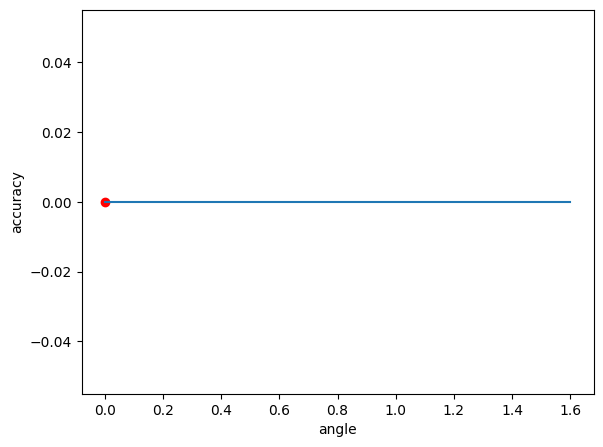

In [18]:
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
# plot the variation of accuracy
# Fix: Slice accuracies to match the length of shearconstraints
ax.plot(shearconstraints, accuracies[:len(shearconstraints)])
ax.set_xlabel("angle")
ax.set_ylabel("accuracy")

# plot the maximum accuracy
# Fix: Calculate maxind on the sliced accuracies to ensure it's within bounds of shearconstraints
maxind = np.argmax(accuracies[:len(shearconstraints)])
plt.scatter(shearconstraints[maxind], accuracies[maxind], c="red")